# SPAD Time-Rabi Ensemble — Hermes camera

> **Goal**: Load raw Hermes time-Rabi acquisitions saved as multi-part `.hrm` files, compute per-pulse-duration averaged signal/reference images, apply optional background subtraction, and plot Rabi diagnostics. Exports processed arrays for downstream batch analysis.

---
## Configuration (edit these cells before running)

**Cell 3** — directory roots:
- `spad_dir`: root folder for SPAD data (contains `hermes/` and `processed/` subdirectories)
- `qm_dir`: root folder for the QM control software dataset

**Cell 4** — per-experiment settings:
- `hrm_file_header`: filename prefix of the continuous acquisition part-files. The notebook finds all files matching `<prefix><integer>.hrm` under `<spad_dir>/hermes/`.
- `qm_file`: path to the QM dataset folder relative to `qm_dir`.
- `spad_background`: stem name of a single-frame background `.hrm` snapshot, or `None` to skip background subtraction.

---
## Processing steps

1. **Load QM dataset** — extracts `t_vec` (sweep axis), `n_avg`, and `n_iteration`.
2. **Discover Hermes part-files** — finds all `<prefix><N>.hrm` files and sorts them by index.
3. **Read header** — extracts camera metadata from the first part-file; determines `integration_time_s` from gated (coarse gate stop − start) or ungated (SummedFrames × HwIntTime) settings.
4. **Load background** (if `spad_background` is set) — reads the single-frame background snapshot, computes `bg_avg_cps` (counts/sec/pixel).
5. **Process all part-files** — streams through each file via memmap, accumulates complete repetitions (each rep = 2 × N frames: signal then reference per pulse duration point), and builds `sig_avg_cps_bgsub` / `ref_avg_cps_bgsub`.
6. **Plot diagnostics** — reference image and full-array Rabi oscillation.
7. **Export** (optional) — saves to `<spad_dir>/processed/`.

---
## What you get in memory
- `sig_avg_cps_bgsub`, `ref_avg_cps_bgsub`: arrays shaped `(N, n_rows, n_cols)` in counts/sec/pixel, background-subtracted if `spad_background` was set.
- `t_vec`: pulse duration sweep axis (ns).
- `n_complete_reps`: number of complete repetitions included in the averages.
- `bg_avg_cps`: background image in counts/sec/pixel (or `None`).
- `header`: Hermes camera header metadata from the first `.hrm` part-file.
- `integration_time_s`: gated or ungated exposure time used to convert raw counts → cps.

---
## Outputs written to disk (optional)
The **"export processed data"** cell saves to `<spad_dir>/processed/`:
- `<base_name>.npz` — compressed arrays
- `<base_name>_header.txt` — JSON metadata

In [132]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import re

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'experiment-main').exists():
            return p
    raise RuntimeError('Could not find workspace root containing experiment-main')

WORKSPACE = find_workspace_root(Path.cwd())
sys.path.insert(0, str(WORKSPACE / 'experiment-main'))

# Hermes SDK (ReadHermesDataFile is pure Python — no DLL needed for file reading)
HERMES_DIR = WORKSPACE / 'qudi-iqo-modules' / 'src' / 'qudi' / 'hardware' / 'camera' / 'Hermes'
if str(HERMES_DIR) not in sys.path:
    sys.path.insert(0, str(HERMES_DIR))
from Hermes import Hermes

from qua_tools_nv2.dataset import DatasetReader
from qua_tools_nv2.nv2_fits import Fitter

In [133]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

In [134]:
hrm_file_header = 'time_rabi_tracking_20260719-143058-775308_iter001'
qm_file = r'Data\2026-07-19\#583_time_rabi_gradient_tracking_145838'


# spad_background = None
spad_background = 'spc3_snap_20260714-190431-366426'  # stem only, no extension

In [135]:
reader = DatasetReader(qm_dir)

qm_path = Path(qm_dir) / Path(qm_file)

ds_folder = reader.resolve_dataset(str(qm_path)).folder
ds = reader.resolve_dataset(ds_folder)
data = reader.load(ds)

t_vec = np.asarray(data['t_vec'], dtype=float) #clock cycles
t_vec = 4*t_vec #4 ns per clock cycle

n_avg = int(data.get('n_avg', 1))
n_iteration = int(data.get('iteration', n_avg - 1)) + 1

print(f'Loaded: {ds.folder}')
print(f'n_avg               : {n_avg}  (requested)')
print(f'n_iteration         : {n_iteration}  (actually completed)')
if n_iteration != n_avg:
    print(f'  experiment was interrupted at {n_iteration / n_avg * 100:.1f}% of target')
print(f'len(t_vec): {len(t_vec)}')
print(f'pulse range         : {t_vec.min():.1f} – {t_vec.max():.1f} ns')
print(f'Expected total frames: {2 * n_iteration * len(t_vec)}')

Loaded: C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD\Data\2026-07-19\#583_time_rabi_gradient_tracking_145838
n_avg               : 500000  (requested)
n_iteration         : 500000  (actually completed)
len(t_vec): 50
pulse range         : 16.0 – 5896.0 ns
Expected total frames: 50000000


In [136]:
spad_dir_path = Path(spad_dir)
hrm_path = spad_dir_path / 'hermes'

# Discover all part-files saved as
#   <prefix><index>.hrm  where <index> is an integer (1, 2, ..., 10, 11, ...)
_prefix = re.sub(r'\d+$', '', str(hrm_file_header))
_part_re = re.compile(r'^' + re.escape(_prefix) + r'(\d+)\.hrm$', re.IGNORECASE)

def _hrm_sort_key(p: Path) -> int:
    m = _part_re.match(p.name)
    return int(m.group(1)) if m else -1

hrm_files = sorted(
    (p for p in hrm_path.glob(f'{_prefix}*.hrm') if _part_re.match(p.name)),
    key=_hrm_sort_key
)

if not hrm_files:
    raise FileNotFoundError(
        f"No .hrm files found matching '{_prefix}<integer>.hrm' in\n  {hrm_path}"
    )

print(f'Found {len(hrm_files)} .hrm file(s):')
for fp in hrm_files:
    print(f'  {fp.name}')

Found 48 .hrm file(s):
  time_rabi_tracking_20260719-143058-775308_iter001.hrm
  time_rabi_tracking_20260719-143058-775308_iter0012.hrm
  time_rabi_tracking_20260719-143058-775308_iter0013.hrm
  time_rabi_tracking_20260719-143058-775308_iter0014.hrm
  time_rabi_tracking_20260719-143058-775308_iter0015.hrm
  time_rabi_tracking_20260719-143058-775308_iter0016.hrm
  time_rabi_tracking_20260719-143058-775308_iter0017.hrm
  time_rabi_tracking_20260719-143058-775308_iter0018.hrm
  time_rabi_tracking_20260719-143058-775308_iter0019.hrm
  time_rabi_tracking_20260719-143058-775308_iter00110.hrm
  time_rabi_tracking_20260719-143058-775308_iter00111.hrm
  time_rabi_tracking_20260719-143058-775308_iter00112.hrm
  time_rabi_tracking_20260719-143058-775308_iter00113.hrm
  time_rabi_tracking_20260719-143058-775308_iter00114.hrm
  time_rabi_tracking_20260719-143058-775308_iter00115.hrm
  time_rabi_tracking_20260719-143058-775308_iter00116.hrm
  time_rabi_tracking_20260719-143058-775308_iter00117.hrm
 

In [137]:
# Extract metadata from first file
frames, header = Hermes.ReadHermesDataFile(str(hrm_files[0]))

print('=== Header (first file) ===')
print(f'  n_frames     : {header.N_frames}')
print(f'  n_counters   : {header.N_counters}')
print(f'  n_rows       : {header.N_rows}')
print(f'  n_cols       : {header.N_cols}')
print(f'  bits/pixel   : {header.bit_x_pix}')
print(f'  n_pixels     : {header.N_pix}')
print(f'  HW integ time: {header.HwIntTime * 1e6:.3f} µs')
print(f'  summed frames: {header.SummedFrames}')
print(f'  coarse gate C1: {header.CoarseGate_C1_ON}  ')
if header.CoarseGate_C1_ON:
    integration_time_s = header.CoarseGate_C1_stopPos - header.CoarseGate_C1_startPos
    print(f'  gated integration time = {integration_time_s * 1e9:.3f} ns')
else:
    integration_time_s = header.SummedFrames * header.HwIntTime
    print(f'  ungated exposure time : {integration_time_s * 1e6:.3f} µs')
    print('  WARNING: CoarseGate_C1_ON is False. If gating was active, the header was not')
    print('  correctly stamped. Use the fallback below to set integration_time_s manually.')

print(f'\n=== Frames (first file) ===')
print(f'  shape : {frames.shape}  (n_counters, n_frames, n_cols, n_rows)')
print(f'  dtype : {frames.dtype}')
print(f'  min/max (counter 0): {frames[0].min()}, {frames[0].max()}')

=== Header (first file) ===
  n_frames     : 1048574
  n_counters   : 1
  n_rows       : 32
  n_cols       : 32
  bits/pixel   : 8
  n_pixels     : 1024
  HW integ time: 10.400 µs
  summed frames: 1
  coarse gate C1: True  
  gated integration time = 300.000 ns

=== Frames (first file) ===
  shape : (1, 1048574, 32, 32)  (n_counters, n_frames, n_cols, n_rows)
  dtype : uint8
  min/max (counter 0): 0, 3


=== Background header ===
  n_frames     : 100
  n_counters   : 1
  n_rows       : 32
  n_cols       : 32
  bits/pixel   : 16
  HW integ time: 10.400 µs
  summed frames: 5000
  coarse gate C1: False
  ungated exposure time : 52000.000 µs

=== Background frames ===
  shape : (100, 32, 32)  (n_frames, n_rows, n_cols)
  dtype : uint16
  min/max: 1, 40811


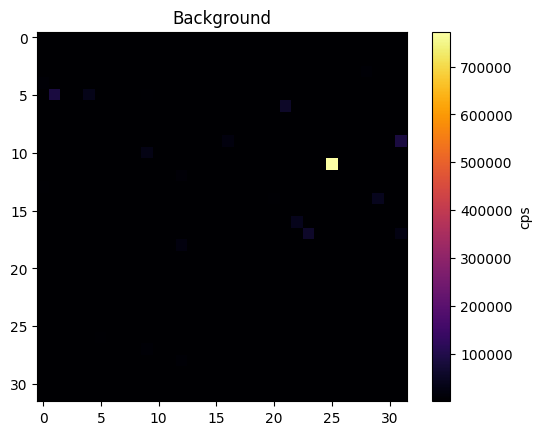

In [138]:
if spad_background is not None:
    bg_path = hrm_path / f'{spad_background}.hrm'
    _, header_bg = Hermes.ReadHermesDataFile(str(bg_path))

    print('=== Background header ===')
    print(f'  n_frames     : {header_bg.N_frames}')
    print(f'  n_counters   : {header_bg.N_counters}')
    print(f'  n_rows       : {header_bg.N_rows}')
    print(f'  n_cols       : {header_bg.N_cols}')
    print(f'  bits/pixel   : {header_bg.bit_x_pix}')
    print(f'  HW integ time: {header_bg.HwIntTime * 1e6:.3f} µs')
    print(f'  summed frames: {header_bg.SummedFrames}')
    print(f'  coarse gate C1: {header_bg.CoarseGate_C1_ON}')
    if header_bg.CoarseGate_C1_ON:
        integration_time_s_bg = header_bg.CoarseGate_C1_stopPos - header_bg.CoarseGate_C1_startPos
        print(f'  gated integration time = {integration_time_s_bg * 1e9:.3f} ns')
    else:
        integration_time_s_bg = header_bg.SummedFrames * header_bg.HwIntTime
        print(f'  ungated exposure time : {integration_time_s_bg * 1e6:.3f} µs')

    dtype_bg = np.uint8 if header_bg.bit_x_pix == 8 else np.uint16
    n_rows_bg, n_cols_bg = header_bg.N_rows, header_bg.N_cols

    DATA_OFFSET = 1032  # 8-byte signature + 1024-byte header
    raw_bg = np.memmap(str(bg_path), dtype=dtype_bg, mode='r', offset=DATA_OFFSET)
    n_frames_bg = raw_bg.size // (n_rows_bg * n_cols_bg)
    frames_bg_arr = raw_bg[:n_frames_bg * n_rows_bg * n_cols_bg].reshape(
        n_frames_bg, n_rows_bg, n_cols_bg
    )

    print(f'\n=== Background frames ===')
    print(f'  shape : {frames_bg_arr.shape}  (n_frames, n_rows, n_cols)')
    print(f'  dtype : {frames_bg_arr.dtype}')
    print(f'  min/max: {frames_bg_arr.min()}, {frames_bg_arr.max()}')

    bg_avg_cps = frames_bg_arr.mean(axis=0).astype(np.float64) / integration_time_s_bg

    del raw_bg, frames_bg_arr

    plt.imshow(bg_avg_cps, cmap='inferno')
    plt.colorbar(label='cps')
    plt.title('Background')
    plt.show()
else:
    bg_avg_cps = None
    header_bg = None
    print('No background file set — skipping background subtraction.')

In [139]:
DATA_OFFSET = 1032   # bytes: 8-byte signature + 1024-byte header

n_rows = header.N_rows
n_cols = header.N_cols
dtype  = np.uint8 if header.bit_x_pix == 8 else np.uint16

F = len(t_vec)
frames_per_rep = 2 * F

sig_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
ref_sum = np.zeros((F, n_rows, n_cols), dtype=np.float64)
n_complete_reps = 0
carry = None

for fp in hrm_files:
    raw = np.memmap(str(fp), dtype=dtype, mode='r', offset=DATA_OFFSET)
    n_frames_file = raw.size // (n_rows * n_cols)
    frames = raw[:n_frames_file * n_rows * n_cols].reshape(n_frames_file, n_rows, n_cols)

    if carry is not None and carry.shape[0] > 0:
        gap = frames_per_rep - (carry.shape[0] % frames_per_rep)
        if gap < frames_per_rep and gap <= n_frames_file:
            combined = np.concatenate([carry, np.array(frames[:gap])], axis=0)
            n_reps_combined = combined.shape[0] // frames_per_rep
            if n_reps_combined > 0:
                rv = combined[:n_reps_combined * frames_per_rep].reshape(
                    n_reps_combined, F, 2, n_rows, n_cols
                )
                sig_sum += rv[:, :, 0, :, :].sum(axis=0, dtype=np.float64)
                ref_sum += rv[:, :, 1, :, :].sum(axis=0, dtype=np.float64)
                n_complete_reps += n_reps_combined
            start_idx = gap
        else:
            carry = np.concatenate([carry, np.array(frames)], axis=0)
            continue
        carry = None
    else:
        start_idx = 0

    n_remaining = n_frames_file - start_idx
    n_complete_here = (n_remaining // frames_per_rep) * frames_per_rep

    if n_complete_here > 0:
        batch = frames[start_idx : start_idx + n_complete_here]
        rep_view = batch.reshape(-1, F, 2, n_rows, n_cols)
        sig_sum += rep_view[:, :, 0, :, :].sum(axis=0, dtype=np.float64)
        ref_sum += rep_view[:, :, 1, :, :].sum(axis=0, dtype=np.float64)
        n_complete_reps += n_complete_here // frames_per_rep

    leftover_start = start_idx + n_complete_here
    if leftover_start < n_frames_file:
        carry = np.array(frames[leftover_start:])

    del raw, frames

dropped = carry.shape[0] if carry is not None else 0
print(f'Complete repetitions : {n_complete_reps}  ({n_complete_reps / n_iteration * 100:.1f}% of {n_iteration} completed)')
if dropped:
    print(f'Dropped trailing     : {dropped} frame(s) (incomplete final repetition)')

sig_avg = sig_sum / n_complete_reps
ref_avg = ref_sum / n_complete_reps

sig_avg_cps = sig_avg / integration_time_s
ref_avg_cps = ref_avg / integration_time_s

if spad_background is not None:
    sig_avg_cps_bgsub = sig_avg_cps - bg_avg_cps
    ref_avg_cps_bgsub = ref_avg_cps - bg_avg_cps
else:
    sig_avg_cps_bgsub = sig_avg_cps
    ref_avg_cps_bgsub = ref_avg_cps

Complete repetitions : 499999  (100.0% of 500000 completed)
Dropped trailing     : 68 frame(s) (incomplete final repetition)


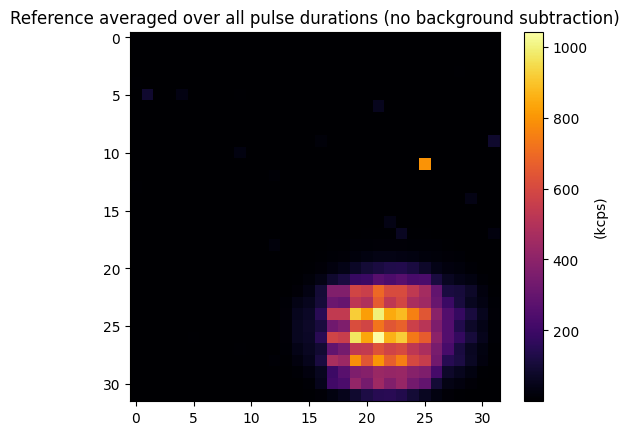

In [140]:
plt.imshow(1e-3 * ref_avg_cps.mean(axis=0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.title('Reference averaged over all pulse durations (no background subtraction)')
plt.show()

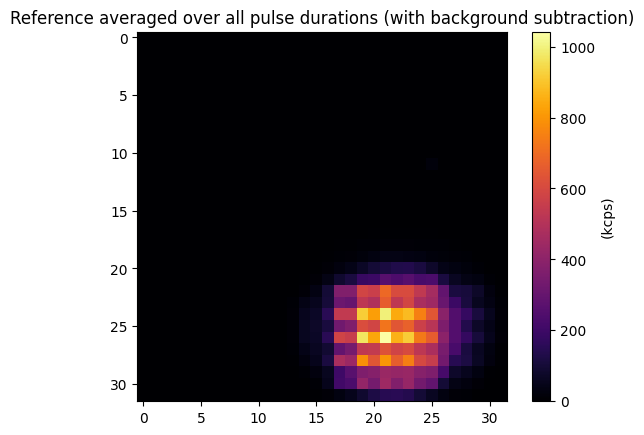

In [141]:
plt.imshow(1e-3 * ref_avg_cps_bgsub.mean(axis=0), cmap='inferno')
plt.colorbar(label='(kcps)')
plt.title('Reference averaged over all pulse durations (with background subtraction)')
plt.show()

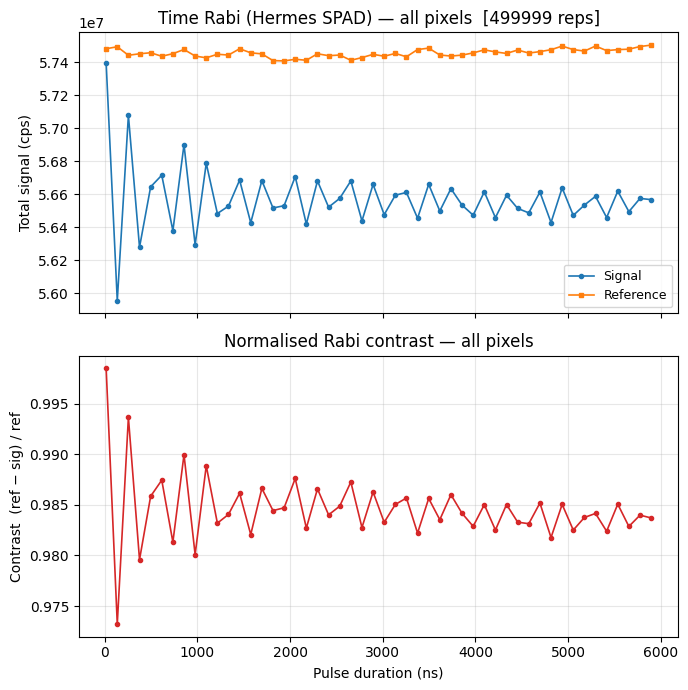

In [142]:
sig_counts = sig_avg_cps_bgsub.sum(axis=(-1, -2))   # (N,)
ref_counts = ref_avg_cps_bgsub.sum(axis=(-1, -2))   # (N,)

with np.errstate(divide='ignore', invalid='ignore'):
    contrast_all = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

axes[0].plot(t_vec, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
axes[0].plot(t_vec, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
axes[0].set_ylabel('Total signal (cps)')
axes[0].set_title(f'Time Rabi (Hermes SPAD) — all pixels  [{n_complete_reps} reps]')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_vec, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
axes[1].set_xlabel('Pulse duration (ns)')
axes[1].set_ylabel('Contrast  (ref − sig) / ref')
axes[1].set_title('Normalised Rabi contrast — all pixels')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

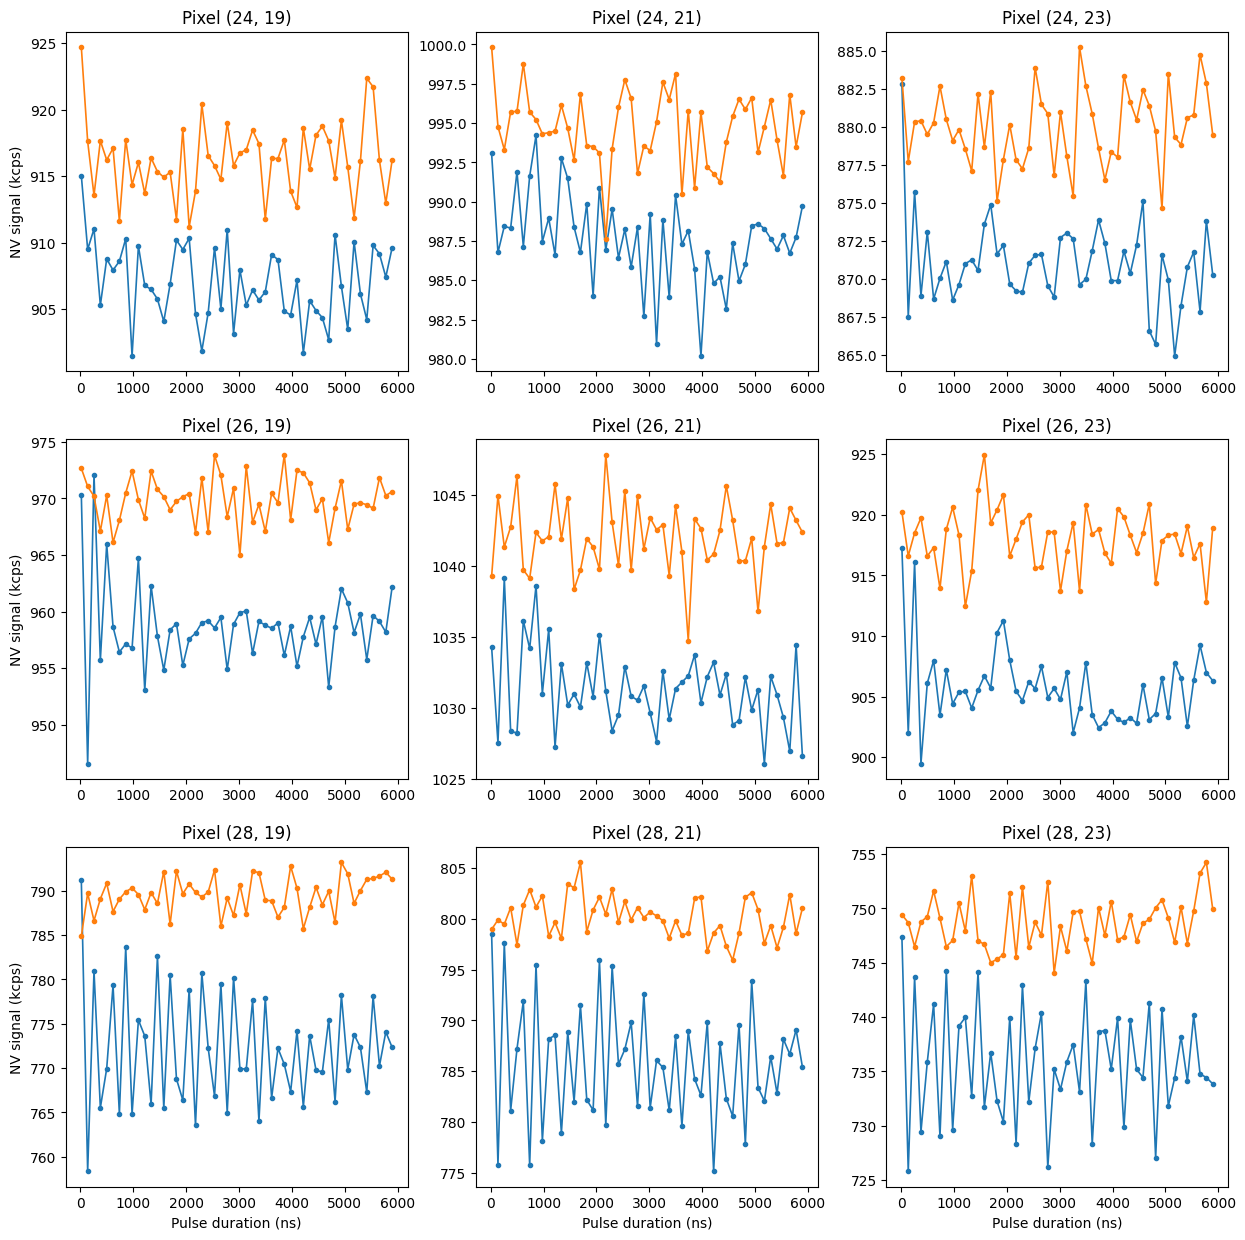

In [143]:
# Signal and reference for each pixel in the 3×3 emitter array
# centred on the brightest pixel in the mean reference image
ref_frame = ref_avg_cps_bgsub.mean(axis=0)  # (rows, cols)
bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)

plt.subplots(3, 3, figsize=(15, 15))

for i in range(3):
    for j in range(3):
        sig_pix = sig_avg_cps_bgsub[:, bright_rc[0] + 2*i - 2, bright_rc[1] + 2*j - 2]
        ref_pix = ref_avg_cps_bgsub[:, bright_rc[0] + 2*i - 2, bright_rc[1] + 2*j - 2]

        plt.subplot(3, 3, i*3 + j + 1)
        plt.plot(t_vec, sig_pix / 1000, 'o-', ms=3, lw=1.2, label='Signal')
        plt.plot(t_vec, ref_pix / 1000, 'o-', ms=3, lw=1.2, label='Reference')
        plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
        if i == 2:
            plt.xlabel('Pulse duration (ns)')
        if j == 0:
            plt.ylabel('NV signal (kcps)')

In [144]:
out_dir = Path(spad_dir) / 'processed'
out_dir.mkdir(parents=True, exist_ok=True)

dataset_tag = re.sub(r'[^A-Za-z0-9_.-]+', '_', Path(qm_file).name)
base_name = f'{hrm_file_header}_{dataset_tag}_avg'
array_path = out_dir / f'{base_name}.npz'
meta_path  = out_dir / f'{base_name}_header.txt'


def _to_builtin(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(k): _to_builtin(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [_to_builtin(v) for v in value]
    try:
        json.dumps(value)
        return value
    except (TypeError, OverflowError):
        return str(value)


def _obj_to_dict(obj):
    try:
        raw = vars(obj)
        if raw:
            return {k: _to_builtin(v) for k, v in raw.items()}
    except TypeError:
        pass
    out = {}
    for name in dir(obj):
        if name.startswith('_'):
            continue
        try:
            val = getattr(obj, name)
        except Exception:
            continue
        if callable(val):
            continue
        out[name] = _to_builtin(val)
    return out


np.savez_compressed(
    array_path,
    sig_avg_cps_bgsub=sig_avg_cps_bgsub,
    ref_avg_cps_bgsub=ref_avg_cps_bgsub,
    t_vec=t_vec,
    n_complete_reps=n_complete_reps,
    bg_avg_cps=bg_avg_cps if spad_background is not None else None,
    bg_filename=str(hrm_path / f'{spad_background}.hrm') if spad_background is not None else None,
)

metadata_export = {
    'export': {
        'array_file': str(array_path),
        'array_shapes': {
            'sig_avg_cps_bgsub': list(sig_avg_cps_bgsub.shape),
            'ref_avg_cps_bgsub': list(ref_avg_cps_bgsub.shape),
            't_vec': list(np.shape(t_vec)),
            'bg_avg_cps': list(np.shape(bg_avg_cps)) if spad_background is not None else None,
        },
    },
    'run_info': {
        'qm_file': str(ds.folder),
        'n_complete_reps': int(n_complete_reps),
    },
    'hrm_data': {
        'hermes measurement metadata': _obj_to_dict(header),
        'integration_time_s': integration_time_s,
        'hermes background metadata': _obj_to_dict(header_bg) if spad_background is not None else None,
    },
}

with open(meta_path, 'w', encoding='utf-8') as f:
    f.write('Hermes time-Rabi processed export metadata\n')
    f.write('=' * 42 + '\n\n')
    f.write(json.dumps(metadata_export, indent=2))

print(f'Saved arrays   -> {array_path}')
print(f'Saved metadata -> {meta_path}')

Saved arrays   -> C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\time_rabi_tracking_20260719-143058-775308_iter001__583_time_rabi_gradient_tracking_145838_avg.npz
Saved metadata -> C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\time_rabi_tracking_20260719-143058-775308_iter001__583_time_rabi_gradient_tracking_145838_avg_header.txt
